# Biopython

引用Biopython

In [902]:
import Bio

安裝版本

In [903]:
print(Bio.__version__)

1.85


### 序列物件

#### 序列操作

In [904]:
from Bio.Seq import Seq

In [905]:
my_seq = Seq("GATCGATGGGCCTATATAGGATCGAAAATCGC")
my_seq

Seq('GATCGATGGGCCTATATAGGATCGAAAATCGC')

In [906]:
print(my_seq)

GATCGATGGGCCTATATAGGATCGAAAATCGC


In [907]:
my_seq[0]

'G'

In [908]:
my_seq[2]

'T'

In [909]:
my_seq[-1]

'C'

取得序列長度

In [910]:
len(my_seq)

32

計算數量

In [911]:
my_seq.count("G")

9

GC含量

In [912]:
100 * (my_seq.count("G") + my_seq.count("C")) / len(my_seq)

46.875

In [913]:
from Bio.SeqUtils import gc_fraction

gc_fraction(my_seq)

0.46875

序列切片

In [914]:
my_seq = Seq("GATCGATGGGCCTATATAGGATCGAAAATCGC")
my_seq[4:12]

Seq('GATGGGCC')

反轉序列

In [915]:
my_seq[::-1]

Seq('CGCTAAAAGCTAGGATATATCCGGGTAGCTAG')

將序列轉換為字串

In [916]:
str(my_seq)

'GATCGATGGGCCTATATAGGATCGAAAATCGC'

連接及新增序列

In [917]:
seq1 = Seq("ACGT")
seq2 = Seq("AACCGG")
seq1 + seq2

Seq('ACGTAACCGG')

#### 核甘酸序列與(反向)互補序列 Nucleotide sequences and (reverse) complements

In [918]:
from Bio.Seq import Seq



my_seq = Seq("GATCGATGGGCCTATATAGGATCGAAAATCGC")


my_seq

Seq('GATCGATGGGCCTATATAGGATCGAAAATCGC')

互補序列

In [919]:
my_seq.complement()

Seq('CTAGCTACCCGGATATATCCTAGCTTTTAGCG')

反向互補序列

In [920]:
my_seq.reverse_complement()

Seq('GCGATTTTCGATCCTATATAGGCCCATCGATC')

#### 轉錄 Transcription

In [921]:
from Bio.Seq import Seq



coding_dna = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")

編碼 DNA

In [922]:
coding_dna

Seq('ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG')

模板 DNA

In [923]:
template_dna = coding_dna.reverse_complement()
template_dna

Seq('CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT')

mRNA

In [924]:
messenger_rna = coding_dna.transcribe()
messenger_rna

Seq('AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG')

利用模板股的轉錄步驟

In [925]:
template_dna.reverse_complement().transcribe()

Seq('AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG')

將 mRNA 反轉錄為編碼股

In [926]:
messenger_rna = Seq("AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG")
messenger_rna.back_transcribe()

Seq('ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG')

#### 轉譯 Translation

In [927]:
from Bio.Seq import Seq



messenger_rna = Seq("AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG")


messenger_rna

Seq('AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG')

將 mRNA 轉譯成蛋白質

In [928]:
messenger_rna.translate()

Seq('MAIVMGR*KGAR*')

直接從編碼 DNA 轉譯

In [929]:
coding_dna = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")
coding_dna.translate()

Seq('MAIVMGR*KGAR*')

使用不同的轉譯對照表

In [930]:
coding_dna.translate(table="Vertebrate Mitochondrial")

Seq('MAIVMGRWKGAR*')

從起始密碼子開始轉譯至終止密碼子結束

In [931]:
coding_dna.translate(to_stop=True)

Seq('MAIVMGR')

##### 密碼子與胺基酸對照表

In [932]:
from Bio.Data import CodonTable

In [933]:
standard_table = CodonTable.unambiguous_dna_by_name["Standard"]
mito_table = CodonTable.unambiguous_dna_by_name["Vertebrate Mitochondrial"]

輸出對照表

In [934]:
print(standard_table)  # 標準

Table 1 Standard, SGC0

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA Stop| A
T | TTG L(s)| TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L(s)| CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I   | ACT T   | AAT N   | AGT S   | T
A | ATC I   | ACC T   | AAC N   | AGC S   | C
A | ATA I   | ACA T   | AAA K   | AGA R   | A
A | ATG M(s)| ACG T   | AAG K   | AGG R   | G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V   | GCG A   | GAG E   | GGG G   | G
--+---------

In [935]:
print(mito_table)  # 脊椎動物粒線體

Table 2 Vertebrate Mitochondrial, SGC1

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA W   | A
T | TTG L   | TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L   | CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I(s)| ACT T   | AAT N   | AGT S   | T
A | ATC I(s)| ACC T   | AAC N   | AGC S   | C
A | ATA M(s)| ACA T   | AAA K   | AGA Stop| A
A | ATG M(s)| ACG T   | AAG K   | AGG Stop| G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V(s)| GCG A   | GAG E   | GGG G   

尋找對應密碼子

In [936]:
mito_table.stop_codons

['TAA', 'TAG', 'AGA', 'AGG']

In [937]:
mito_table.start_codons

['ATT', 'ATC', 'ATA', 'ATG', 'GTG']

In [938]:
mito_table.forward_table["ACG"]

'T'

#### 進階序列操作

In [939]:
from Bio.Seq import Seq

比較序列

In [940]:
seq1 = Seq("ACGT")
"ACGT" == seq1

True

未知內容的序列

In [941]:
unknown_seq = Seq(None, 10)
unknown_seq

Seq(None, length=10)

僅有部分定義的序列

In [942]:
seq = Seq({117512683: "TTGAAAACCTGAATGTGAGAGTCAGTCAAGGATAGT"}, length=159345973)

##### MutableSeq 物件

Seq 不可修改

In [943]:
my_seq = Seq("GCCATTGTAATGGGCCGCTGAAAGGGTGCCCGA")

轉換成 MutableSeq 物件

In [944]:
from Bio.Seq import MutableSeq

mutable_seq = MutableSeq("GCCATTGTAATGGGCCGCTGAAAGGGTGCCCGA")

In [945]:
mutable_seq[5] = "C"
mutable_seq

MutableSeq('GCCATCGTAATGGGCCGCTGAAAGGGTGCCCGA')

In [946]:
mutable_seq.remove("T")
mutable_seq

MutableSeq('GCCACGTAATGGGCCGCTGAAAGGGTGCCCGA')

In [947]:
mutable_seq.reverse()
mutable_seq

MutableSeq('AGCCCGTGGGAAAGTCGCCGGGTAATGCACCG')

轉回 Seq 物件

In [948]:
from Bio.Seq import Seq

new_seq = Seq(mutable_seq)
new_seq

Seq('AGCCCGTGGGAAAGTCGCCGGGTAATGCACCG')

尋找子序列 find

In [949]:
from Bio.Seq import Seq, MutableSeq
seq = Seq("GCCATTGTAATGGGCCGCTGAAAGGGTGCCCGA")

In [950]:
seq.find("CC")

1

當未找到目標時回傳 -1

In [951]:
seq.find("ACTG")

-1

從最後開始往回尋找

In [952]:
seq.rfind("CC")

29

尋找子序列 index

In [953]:
seq.index("ATGGGCCGC")  # str 字串

9

In [954]:
seq.index(Seq("ATGGGCCGC"))  # Seq 物件

9

In [955]:
seq.index(MutableSeq("ATGGGCCGC"))  # MutableSeq 物件

9

尋找多個子序列 search

In [956]:
for index, sub in seq.search(["CC", "GGG", "CC"]):
    print(index, sub)

1 CC
11 GGG
14 CC
23 GGG
28 CC
29 CC


直接使用字串操作

In [957]:
from Bio.Seq import reverse_complement, transcribe, back_transcribe, translate
my_string = "GCTGTTATGGGTCGTTGGAAGGGTGGTCGTGCTGCTGGTTAG"

In [958]:
reverse_complement(my_string)

'CTAACCAGCAGCACGACCACCCTTCCAACGACCCATAACAGC'

In [959]:
transcribe(my_string)

'GCUGUUAUGGGUCGUUGGAAGGGUGGUCGUGCUGCUGGUUAG'

In [960]:
back_transcribe(my_string)

'GCTGTTATGGGTCGTTGGAAGGGTGGTCGTGCTGCTGGTTAG'

In [961]:
translate(my_string)

'AVMGRWKGGRAAG*'

### 序列輸入/輸出

In [972]:
from Bio import SeqIO

讀取 fasta 檔案

In [971]:
for seq_record in SeqIO.parse("ls_orchid.fasta", "fasta"):
    print(seq_record.id)
    print(repr(seq_record.seq))
    print(len(seq_record))

gi|2765658|emb|Z78533.1|CIZ78533
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGATGAGACCGTGG...CGC')
740
gi|2765657|emb|Z78532.1|CCZ78532
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAACAG...GGC')
753
gi|2765656|emb|Z78531.1|CFZ78531
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGCAG...TAA')
748
gi|2765655|emb|Z78530.1|CMZ78530
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAAACAACAT...CAT')
744
gi|2765654|emb|Z78529.1|CLZ78529
Seq('ACGGCGAGCTGCCGAAGGACATTGTTGAGACAGCAGAATATACGATTGAGTGAA...AAA')
733
gi|2765652|emb|Z78527.1|CYZ78527
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGTAG...CCC')
718
gi|2765651|emb|Z78526.1|CGZ78526
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGTAG...TGT')
730
gi|2765650|emb|Z78525.1|CAZ78525
Seq('TGTTGAGATAGCAGAATATACATCGAGTGAATCCGGAGGACCTGTGGTTATTCG...GCA')
704
gi|2765649|emb|Z78524.1|CFZ78524
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGATAGTAG...AGC')
740
gi|2765648|emb|Z78523.1|CHZ78523
Seq('CGTAACCAGGTTTCCGT

### 範例

#### 核甘酸圓點圖

用以比較兩核苷酸序列的相似性

In [975]:
from Bio import SeqIO

with open("ls_orchid.fasta") as in_handle:
    record_iterator = SeqIO.parse(in_handle, "fasta")
    rec_one = next(record_iterator)
    rec_two = next(record_iterator)

In [976]:
window = 7
seq_one = rec_one.seq.upper()
seq_two = rec_two.seq.upper()
data = [
    [
        (seq_one[i : i + window] != seq_two[j : j + window])
        for j in range(len(seq_one) - window)
    ]
    for i in range(len(seq_two) - window)
]

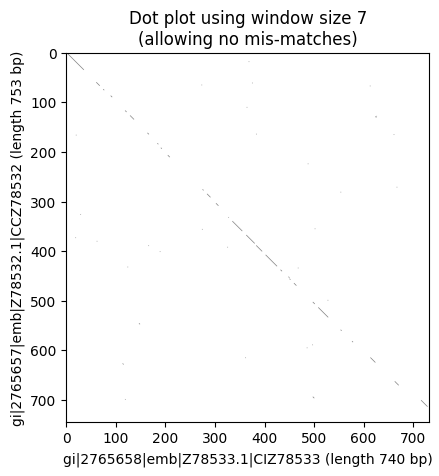

In [ ]:
import pylab

pylab.gray()
pylab.imshow(data)
pylab.xlabel("%s (length %i bp)" % (rec_one.id, len(rec_one)))
pylab.ylabel("%s (length %i bp)" % (rec_two.id, len(rec_two)))
pylab.title("Dot plot using window size %i\n(allowing no mis-matches)" % window)
pylab.show()